# Phase 3 — Heuristic Admissibility & Consistency

This notebook proves, tests, and visualises the admissibility and consistency
of three heuristics for A* TSP:

| Heuristic | Description |
|-----------|-------------|
| **Null** | h(n) = 0 — trivially admissible (UCS) |
| **Min-edge** | h(n) = remaining edges × global min edge |
| **MST** | h(n) = MST cost over unvisited cities |

**Key definitions:**
- **Admissible**: h(n) ≤ true remaining cost for every state
- **Consistent**: h(n) ≤ cost(n → n') + h(n') for every successor n'
- A consistent heuristic is always admissible (but not vice versa)

## Cell 1 — Imports and path setup

In [2]:
import sys, os, math, time
from itertools import permutations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Adjust paths to your project layout
BASE = os.path.abspath('..')
sys.path.extend([
    os.path.join(BASE, 'phase1_foundation'),
    os.path.join(BASE, 'phase2_astar'),
    os.path.join(BASE, 'phase3_heuristics'),
])

from tsp import City, build_distance_matrix, generate_random_cities
from state import TSPState, make_start_state
from baseline import brute_force_tsp, tour_cost
from astar import astar_tsp, null_heuristic, min_edge_heuristic
from heuristic_mst import mst_heuristic, prim_mst_cost

print('All imports OK')

All imports OK


## Cell 2 — Shared utilities

In [3]:
def collect_all_states(dist: list, start: int = 0) -> list:
    """
    BFS over the TSP state space. Returns every reachable TSPState.
    Only feasible for small n (≤ 10).
    """
    n      = len(dist)
    queue  = [make_start_state(start)]
    seen   = set()
    states = []

    while queue:
        s   = queue.pop(0)
        key = (s.current_city, s.visited)
        if key in seen:
            continue
        seen.add(key)
        states.append(s)
        if not s.is_goal(n):
            queue.extend(s.expand(dist))

    return states


def true_remaining_cost(state: TSPState, dist: list) -> float:
    """
    Brute-force the optimal cost to complete the tour from this state.
    Used as ground truth for admissibility checking.
    """
    n         = len(dist)
    unvisited = [c for c in range(n) if c not in state.visited]

    if not unvisited:
        return dist[state.current_city][state.path[0]]

    best = float('inf')
    for perm in permutations(unvisited):
        cost  = dist[state.current_city][perm[0]]
        cost += sum(dist[perm[i]][perm[i+1]] for i in range(len(perm)-1))
        cost += dist[perm[-1]][state.path[0]]
        best  = min(best, cost)

    return best


HEURISTICS = {
    'Null (h=0)' : null_heuristic,
    'Min-edge'   : min_edge_heuristic,
    'MST'        : mst_heuristic,
}

COLORS = {
    'Null (h=0)' : '#888780',
    'Min-edge'   : '#378ADD',
    'MST'        : '#1D9E75',
}

print('Utilities defined.')

Utilities defined.


## Cell 3 — Standard 5-city test instance

In [4]:
cities_5 = [
    City('A', 0, 0), City('B', 2, 4), City('C', 5, 2),
    City('D', 6, 6), City('E', 1, 7),
]
dist_5 = build_distance_matrix(cities_5)

states_5   = collect_all_states(dist_5)
bf_path, bf_cost = brute_force_tsp(dist_5)

print(f'Cities       : {[c.name for c in cities_5]}')
print(f'States found : {len(states_5)}')
print(f'Optimal tour : {" → ".join(cities_5[i].name for i in bf_path)}')
print(f'Optimal cost : {bf_cost:.4f}')

Cities       : ['A', 'B', 'C', 'D', 'E']
States found : 33
Optimal tour : A → B → E → D → C → A
Optimal cost : 22.2417


## Cell 4 — Admissibility proof by exhaustion

For every reachable state, verify **h(n) ≤ true_remaining_cost(n)**.
If zero violations are found, the heuristic is admissible by exhaustion.

In [5]:
def check_admissibility(states, dist, heuristics):
    results = {}

    for h_name, h_fn in heuristics.items():
        violations   = []
        h_vals       = []
        true_vals    = []
        gaps         = []

        for s in states:
            h_val    = h_fn(s, dist)
            true_val = true_remaining_cost(s, dist)
            gap      = true_val - h_val   # positive = underestimate (good)

            h_vals.append(h_val)
            true_vals.append(true_val)
            gaps.append(gap)

            if h_val > true_val + 1e-6:
                violations.append((s, h_val, true_val))

        results[h_name] = {
            'violations' : violations,
            'h_vals'     : h_vals,
            'true_vals'  : true_vals,
            'gaps'       : gaps,
            'avg_gap'    : sum(gaps) / len(gaps),
            'max_gap'    : max(gaps),
            'min_gap'    : min(gaps),
        }

        status = 'ADMISSIBLE' if not violations else f'VIOLATED ({len(violations)}x)'
        print(f'  {h_name:<14} | {status:<22} | avg gap={sum(gaps)/len(gaps):.3f} | '
              f'min gap={min(gaps):.3f} | max gap={max(gaps):.3f}')

    return results


print(f'Checking admissibility across {len(states_5)} states...\n')
print(f'  {"Heuristic":<14} | {"Result":<22} | avg gap       | min gap    | max gap')
print(f'  {"-"*14} | {"-"*22} | {"-"*13} | {"-"*10} | {"-"*10}')

adm_results = check_admissibility(states_5, dist_5, HEURISTICS)

print('\nInterpretation:')
print('  gap = true_remaining - h(n)')
print('  gap >= 0 always → admissible (never overestimates)')
print('  gap closer to 0 → tighter / more informed heuristic')

Checking admissibility across 33 states...

  Heuristic      | Result                 | avg gap       | min gap    | max gap
  -------------- | ---------------------- | ------------- | ---------- | ----------
  Null (h=0)     | ADMISSIBLE             | avg gap=12.668 | min gap=4.472 | max gap=22.242
  Min-edge       | ADMISSIBLE             | avg gap=4.136 | min gap=0.000 | max gap=7.400
  MST            | ADMISSIBLE             | avg gap=0.514 | min gap=0.000 | max gap=2.599

Interpretation:
  gap = true_remaining - h(n)
  gap >= 0 always → admissible (never overestimates)
  gap closer to 0 → tighter / more informed heuristic


## Cell 5 — Visualise h(n) vs true remaining cost

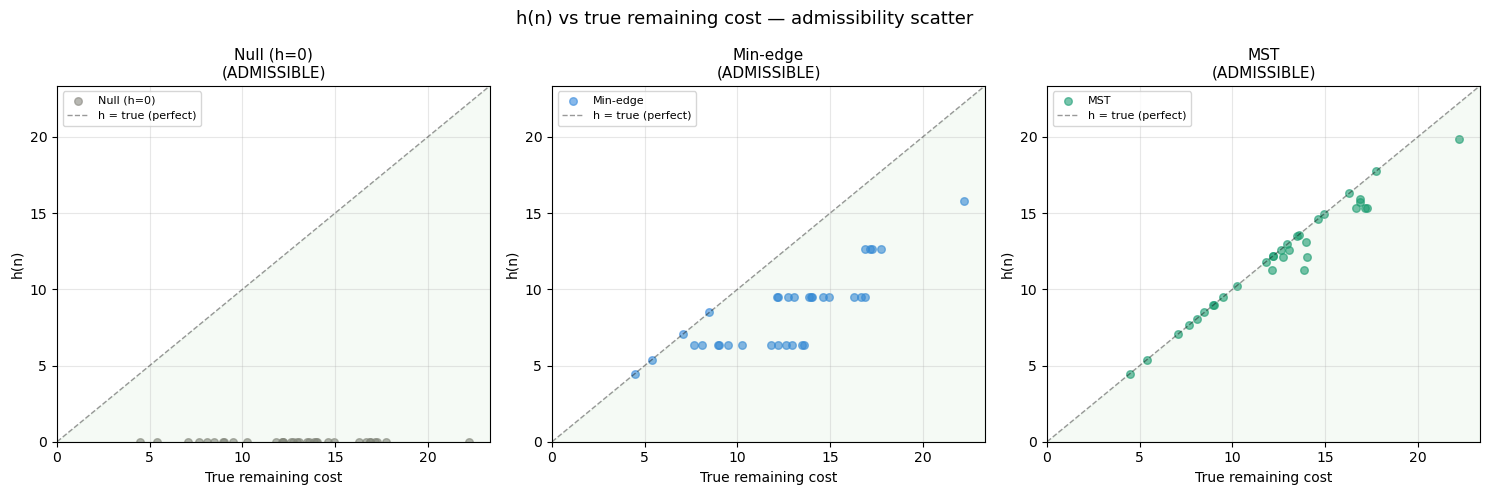

Saved → results/charts/admissibility_scatter.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('h(n) vs true remaining cost — admissibility scatter', fontsize=13)

for ax, (h_name, res) in zip(axes, adm_results.items()):
    true_vals = res['true_vals']
    h_vals    = res['h_vals']
    color     = COLORS[h_name]

    ax.scatter(true_vals, h_vals, alpha=0.6, s=30, color=color, label=h_name)

    # Perfect heuristic line (h = true)
    lim = max(max(true_vals), max(h_vals)) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.4, label='h = true (perfect)')

    # Shade the admissible region
    ax.fill_between([0, lim], [0, 0], [0, lim], alpha=0.04, color='green')

    violations = res['violations']
    if violations:
        vx = [true_remaining_cost(s, dist_5) for s, _, _ in violations]
        vy = [h for _, h, _ in violations]
        ax.scatter(vx, vy, color='red', s=60, marker='x', label='violation', zorder=5)

    ax.set_title(f'{h_name}\n({"ADMISSIBLE" if not violations else "VIOLATED"})',
                 fontsize=11)
    ax.set_xlabel('True remaining cost')
    ax.set_ylabel('h(n)')
    ax.legend(fontsize=8)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('../results/charts', exist_ok=True)
plt.savefig('../results/charts/admissibility_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/charts/admissibility_scatter.png')

## Cell 6 — Gap distribution: how tight is each heuristic?

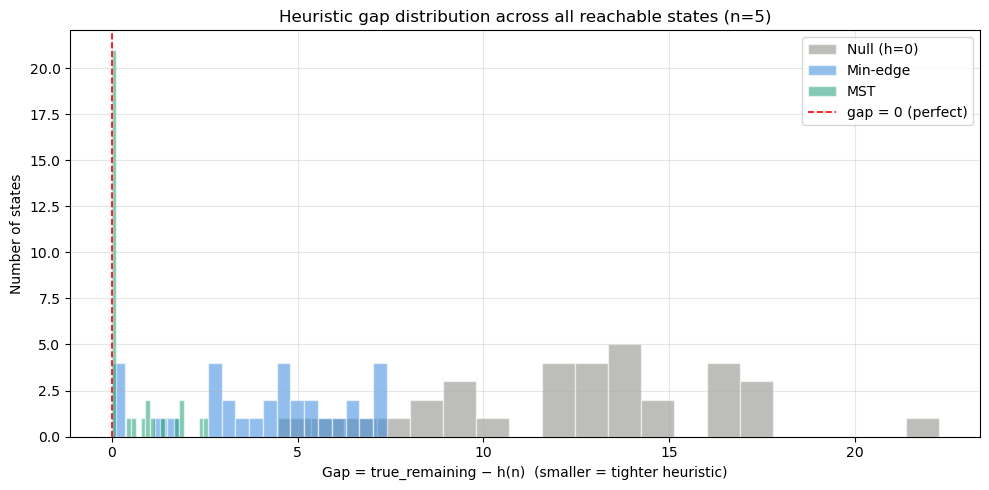

Saved → results/charts/gap_distribution.png

Gap summary (lower avg gap = more informed heuristic):
  Null (h=0)    : avg=12.668  min= 4.472  max=22.242
  Min-edge      : avg= 4.136  min= 0.000  max= 7.400
  MST           : avg= 0.514  min= 0.000  max= 2.599


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

for h_name, res in adm_results.items():
    gaps = res['gaps']
    ax.hist(gaps, bins=20, alpha=0.55, label=h_name,
            color=COLORS[h_name], edgecolor='white')

ax.axvline(0, color='red', linewidth=1.2, linestyle='--', label='gap = 0 (perfect)')
ax.set_xlabel('Gap = true_remaining − h(n)  (smaller = tighter heuristic)')
ax.set_ylabel('Number of states')
ax.set_title('Heuristic gap distribution across all reachable states (n=5)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/charts/gap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/charts/gap_distribution.png')
print()
print('Gap summary (lower avg gap = more informed heuristic):')
for h_name, res in adm_results.items():
    print(f'  {h_name:<14}: avg={res["avg_gap"]:6.3f}  '
          f'min={res["min_gap"]:6.3f}  max={res["max_gap"]:6.3f}')

## Cell 7 — Consistency check

A heuristic is **consistent** if for every state `n` and every successor `n'`:

```
h(n) ≤ cost(n → n') + h(n')
```

Consistency implies admissibility. A consistent heuristic means A* never
needs to re-expand a state — the first path found to any state is optimal.

In [8]:
def check_consistency(states, dist, heuristics):
    n       = len(dist)
    results = {}

    for h_name, h_fn in heuristics.items():
        violations = []
        checks     = 0

        for state in states:
            if state.is_goal(n):
                continue

            h_n = h_fn(state, dist)

            for succ in state.expand(dist):
                edge_cost = dist[state.current_city][succ.current_city]
                h_succ    = h_fn(succ, dist)
                checks   += 1

                # Consistency: h(n) <= edge_cost + h(n')
                if h_n > edge_cost + h_succ + 1e-6:
                    violations.append({
                        'state'    : state,
                        'successor': succ,
                        'h_n'      : h_n,
                        'edge'     : edge_cost,
                        'h_succ'   : h_succ,
                        'deficit'  : h_n - (edge_cost + h_succ),
                    })

        status = 'CONSISTENT' if not violations else f'INCONSISTENT ({len(violations)}x)'
        results[h_name] = {
            'violations': violations,
            'checks'    : checks,
        }
        print(f'  {h_name:<14} | {status:<26} | edges checked: {checks}')

    return results


print(f'Checking consistency across all state→successor edges...\n')
print(f'  {"Heuristic":<14} | {"Result":<26} | edges checked')
print(f'  {"-"*14} | {"-"*26} | {"-"*13}')

con_results = check_consistency(states_5, dist_5, HEURISTICS)

print('\nNote: MST is consistent — provable via the cut property of MSTs.')
print('Min-edge may be inconsistent on some instances despite being admissible.')

Checking consistency across all state→successor edges...

  Heuristic      | Result                     | edges checked
  -------------- | -------------------------- | -------------
  Null (h=0)     | CONSISTENT                 | edges checked: 52
  Min-edge       | CONSISTENT                 | edges checked: 52
  MST            | CONSISTENT                 | edges checked: 52

Note: MST is consistent — provable via the cut property of MSTs.
Min-edge may be inconsistent on some instances despite being admissible.


## Cell 8 — Visualise consistency violations (triangle inequality)

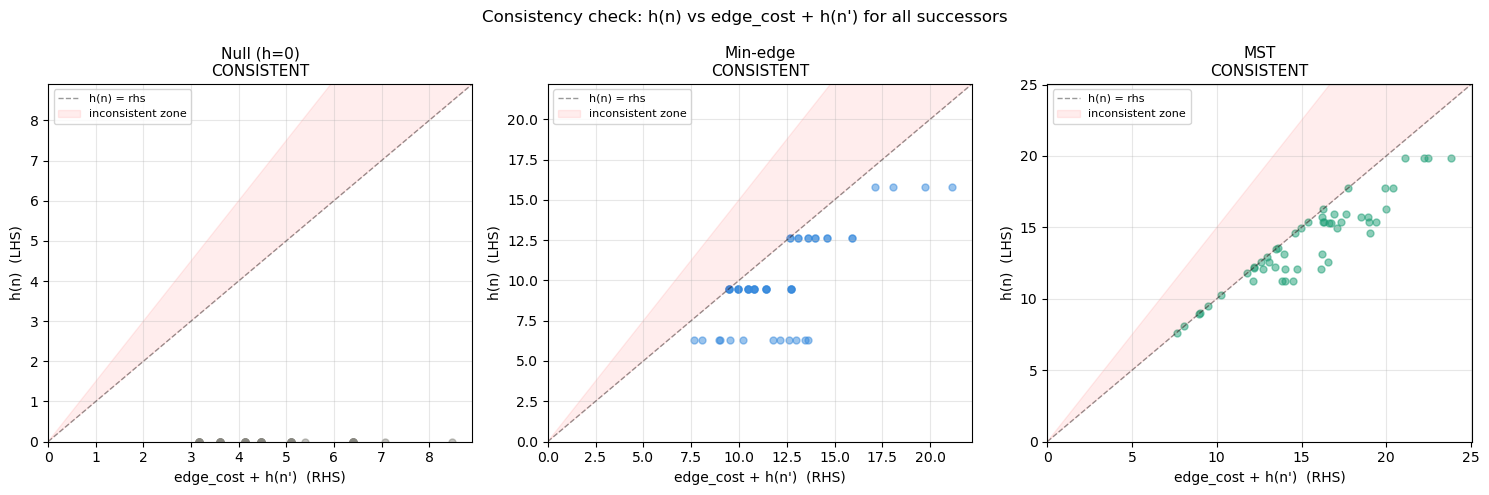

Saved → results/charts/consistency_scatter.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Consistency check: h(n) vs edge_cost + h(n\') for all successors', fontsize=12)

for ax, (h_name, res) in zip(axes, con_results.items()):
    h_fn  = HEURISTICS[h_name]
    color = COLORS[h_name]

    lhs_vals = []   # h(n)
    rhs_vals = []   # edge + h(n')

    for state in states_5:
        if state.is_goal(len(dist_5)):
            continue
        h_n = h_fn(state, dist_5)
        for succ in state.expand(dist_5):
            edge   = dist_5[state.current_city][succ.current_city]
            h_succ = h_fn(succ, dist_5)
            lhs_vals.append(h_n)
            rhs_vals.append(edge + h_succ)

    ax.scatter(rhs_vals, lhs_vals, alpha=0.5, s=25, color=color)

    lim = max(max(rhs_vals), max(lhs_vals)) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.4, label='h(n) = rhs')
    ax.fill_between([0, lim], [0, lim], [0, lim*1.5],
                    alpha=0.07, color='red', label='inconsistent zone')

    n_viol = len(res['violations'])
    label  = 'CONSISTENT' if n_viol == 0 else f'INCONSISTENT ({n_viol}x)'
    ax.set_title(f'{h_name}\n{label}', fontsize=11)
    ax.set_xlabel('edge_cost + h(n\')  (RHS)')
    ax.set_ylabel('h(n)  (LHS)')
    ax.legend(fontsize=8)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/charts/consistency_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/charts/consistency_scatter.png')

## Cell 9 — Nodes expanded: how heuristic quality affects search

In [10]:
sizes   = [5, 6, 7, 8, 9, 10]
results = {h: {'nodes': [], 'times': []} for h in HEURISTICS}

print(f'{"n":>4}  ', end='')
for h in HEURISTICS:
    print(f'{h:>14}', end='')
print()
print('-' * (4 + 14 * len(HEURISTICS)))

for n in sizes:
    cities = generate_random_cities(n, seed=42)
    dist   = build_distance_matrix(cities)
    print(f'{n:>4}  ', end='')

    for h_name, h_fn in HEURISTICS.items():
        r = astar_tsp(dist, h_fn)
        results[h_name]['nodes'].append(r.nodes_expanded if r else None)
        results[h_name]['times'].append(r.runtime_ms if r else None)
        print(f'{r.nodes_expanded if r else "N/A":>14}', end='')

    print()

   n      Null (h=0)      Min-edge           MST
----------------------------------------------
   5              29            24             9
   6              72            51             8
   7             177           135            12
   8             417           370            17
   9             957           996            20
  10            2091          2145            25


## Cell 10 — Nodes expanded chart (striking success)

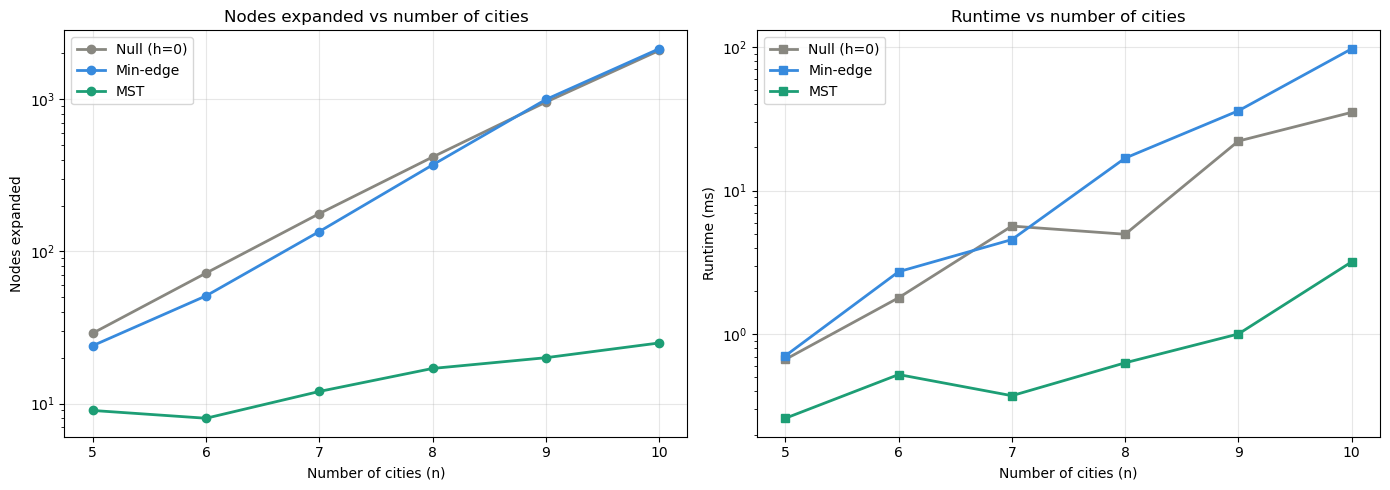

Saved → results/charts/nodes_runtime_comparison.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for h_name in HEURISTICS:
    nodes = results[h_name]['nodes']
    times = results[h_name]['times']
    color = COLORS[h_name]

    valid_sizes_n = [s for s, v in zip(sizes, nodes) if v is not None]
    valid_nodes   = [v for v in nodes if v is not None]
    valid_times   = [v for v in times if v is not None]

    ax1.plot(valid_sizes_n, valid_nodes, marker='o', label=h_name,
             color=color, linewidth=2, markersize=6)
    ax2.plot(valid_sizes_n, valid_times, marker='s', label=h_name,
             color=color, linewidth=2, markersize=6)

ax1.set_title('Nodes expanded vs number of cities', fontsize=12)
ax1.set_xlabel('Number of cities (n)')
ax1.set_ylabel('Nodes expanded')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title('Runtime vs number of cities', fontsize=12)
ax2.set_xlabel('Number of cities (n)')
ax2.set_ylabel('Runtime (ms)')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/charts/nodes_runtime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/charts/nodes_runtime_comparison.png')

## Cell 11 — Striking failure: A* memory explosion at large n

In [12]:
# State space grows as sum_{k=0}^{n-1} C(n-1,k)*k! = O(n!)
# Show this theoretical blow-up vs what A* + MST actually expands

ns           = list(range(4, 16))
theoretical  = [math.factorial(n - 1) for n in ns]   # worst case (UCS)
mst_expanded = []

print('Computing MST A* node counts (this may take a moment for n>11)...')
for n in ns:
    cities = generate_random_cities(n, seed=42)
    dist   = build_distance_matrix(cities)

    t0 = time.perf_counter()
    r  = astar_tsp(dist, mst_heuristic)
    elapsed = time.perf_counter() - t0

    expanded = r.nodes_expanded if r else None
    mst_expanded.append(expanded)
    print(f'  n={n:2d} | expanded={str(expanded):>8} | time={elapsed*1000:7.1f}ms '
          f'| theoretical worst={math.factorial(n-1):>12,}')

Computing MST A* node counts (this may take a moment for n>11)...
  n= 4 | expanded=       5 | time=    0.3ms | theoretical worst=           6
  n= 5 | expanded=       9 | time=    0.6ms | theoretical worst=          24
  n= 6 | expanded=       8 | time=    0.5ms | theoretical worst=         120
  n= 7 | expanded=      12 | time=    1.1ms | theoretical worst=         720
  n= 8 | expanded=      17 | time=    1.3ms | theoretical worst=       5,040
  n= 9 | expanded=      20 | time=    2.0ms | theoretical worst=      40,320
  n=10 | expanded=      25 | time=    3.4ms | theoretical worst=     362,880
  n=11 | expanded=      29 | time=    4.9ms | theoretical worst=   3,628,800
  n=12 | expanded=      38 | time=    6.7ms | theoretical worst=  39,916,800
  n=13 | expanded=      23 | time=    6.2ms | theoretical worst= 479,001,600
  n=14 | expanded=      25 | time=    8.5ms | theoretical worst=6,227,020,800
  n=15 | expanded=      25 | time=    7.3ms | theoretical worst=87,178,291,200


## Cell 12 — Failure chart: exponential wall

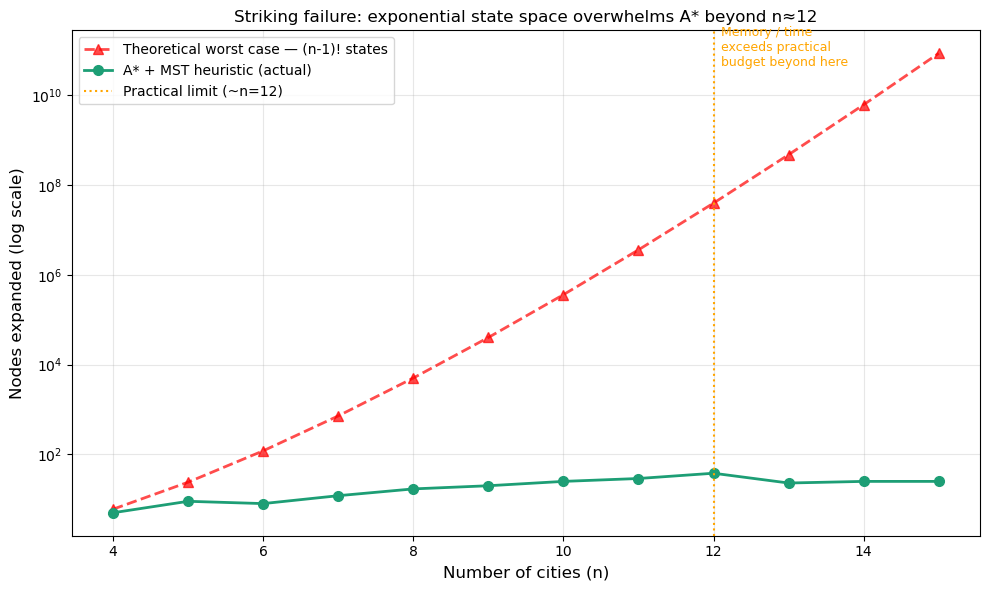

Saved → results/charts/exponential_failure.png

This is your "striking failure" slide — A* + MST is still exponential.
Improvement suggestion: beam search, LKH, or ML-based heuristic.


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(ns, theoretical, 'r--', marker='^', linewidth=2,
        markersize=7, label='Theoretical worst case — (n-1)! states', alpha=0.7)

valid_ns  = [n for n, v in zip(ns, mst_expanded) if v is not None]
valid_exp = [v for v in mst_expanded if v is not None]
ax.plot(valid_ns, valid_exp, color='#1D9E75', marker='o', linewidth=2,
        markersize=7, label='A* + MST heuristic (actual)')

# Mark the practical limit
LIMIT_N = 12
ax.axvline(LIMIT_N, color='orange', linewidth=1.5, linestyle=':',
           label=f'Practical limit (~n={LIMIT_N})')
ax.text(LIMIT_N + 0.1, ax.get_ylim()[1] * 0.5,
        'Memory / time\nexceeds practical\nbudget beyond here',
        fontsize=9, color='orange')

ax.set_yscale('log')
ax.set_xlabel('Number of cities (n)', fontsize=12)
ax.set_ylabel('Nodes expanded (log scale)', fontsize=12)
ax.set_title('Striking failure: exponential state space overwhelms A* beyond n≈12',
             fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/charts/exponential_failure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/charts/exponential_failure.png')
print()
print('This is your "striking failure" slide — A* + MST is still exponential.')
print('Improvement suggestion: beam search, LKH, or ML-based heuristic.')

## Cell 13 — Summary table for slides

In [14]:
import csv

summary_rows = []

for n in [5, 6, 7, 8]:
    cities = generate_random_cities(n, seed=42)
    dist   = build_distance_matrix(cities)

    row = {'n': n}
    for h_name, h_fn in HEURISTICS.items():
        r = astar_tsp(dist, h_fn)
        row[f'{h_name}_nodes']   = r.nodes_expanded if r else 'N/A'
        row[f'{h_name}_time_ms'] = f'{r.runtime_ms:.2f}' if r else 'N/A'
        row[f'{h_name}_cost']    = f'{r.cost:.4f}' if r else 'N/A'
    summary_rows.append(row)

os.makedirs('../results', exist_ok=True)
csv_path = '../results/heuristic_summary.csv'

with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=summary_rows[0].keys())
    writer.writeheader()
    writer.writerows(summary_rows)

print(f'Summary saved → {csv_path}\n')
print(f'{"n":>4}  {"Null nodes":>12} {"Min-edge":>12} {"MST":>12}')
print('-' * 44)
for row in summary_rows:
    print(f"{row['n']:>4}  "
          f"{str(row['Null (h=0)_nodes']):>12} "
          f"{str(row['Min-edge_nodes']):>12} "
          f"{str(row['MST_nodes']):>12}")

print()
print('All charts saved to results/charts/')
print('Ready to generate PowerPoint slides.')

Summary saved → ../results/heuristic_summary.csv

   n    Null nodes     Min-edge          MST
--------------------------------------------
   5            29           24            9
   6            72           51            8
   7           177          135           12
   8           417          370           17

All charts saved to results/charts/
Ready to generate PowerPoint slides.
